## Figure 3: Building duplex consensus metrics and metrics compilation output

This script is used to generate the following plots:

**e**: Percentage of molecules aligned within the targeted regions for 10 different experiments, generated by the Integrated duplex metrics.

**f** and **g**: Optimal libraries



In [ ]:
# --- 1. Setup: imports --------------------------------------------------------

import pandas as pd
import os
import re
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm
import numpy as np
from sklearn import preprocessing

In [ ]:
# --- 2. Paths -------------------------------------------------
# Wetlab analysis data
wetlab_analysis_dir = '/data/bbg/projects/prominent/analysis/wetlab_analysis/data'
# Plots directory
plotsdir = f"{wetlab_analysis_dir}/plots"
# Integrated duplex metrics
data = pd.read_table("/data/bbg/projects/prominent/analysis/wetlab_analysis/data/output_data/2026-03-18.WetDryMetrics.tsv")
# data = pd.read_table("/data/bbg/projects/prominent/analysis/wetlab_analysis/data/output_data/2025-12-23.WetDryMetrics.tsv")


In [4]:
list(data.columns)

['PROJECT',
 'Sample ID',
 'IRB_subsample_id',
 'WetLab>>Sample type',
 'WetLab>>Panel',
 'WetLab>>Panel Size (Kb)',
 'WetLab>>Kit',
 'WetLab>>Quantification gDNA --> Qubit conc. (ng/ul)',
 'WetLab>>DNA integrity --> DIN',
 'WetLab>>Input (ng)',
 'WetLab>>Quantification (after fragmentation) --> DNA amount (ng)',
 'WetLab>>TapeStation (after fragmentation) --> Size (bp)',
 'WetLab>>Quantification (after ligation) --> DNA amount (ng)',
 'WetLab>>TapeStation (after ligation) --> Size (bp)',
 'WetLab>>qPCR --> Unique DNA amount (fmol)',
 'WetLab>>Real diversity --> fmol to PCR1',
 'WetLab>>Quantification POST-PCR1 --> DNA amount (ng)',
 'WetLab>>Real input to capture --> DNA amount (ng)',
 'WetLab>>TapeStation after PCR1 --> Size (bp)',
 'WetLab>>Quantification POST-PCR2 --> Qubit conc. (ng/ul)',
 'WetLab>>Quantification POST-PCR2 --> DNA amount (ng)',
 'WetLab>>TapeStation after PCR2 --> Size (bp)',
 'WetLab>>Quantification POST-PCR3 --> Qubit conc. (ng/ul)',
 'WetLab>>Quantification POS

## ON TARGET percentages

In [5]:
data["OptimalReadXDuplexRead"] = (data['FamMetrics>>total_GBs_for_optimal']/300*1e9) / data['FamMetrics>>all.duplex.dscs']
subset_data = data[['PROJECT', 'Sample ID', 'BamQC>>raw.percentage_aligned_on_target','ANALYSIS_BATCH',
                    'BamQC>>am.percentage_aligned_on_target',
                    'BamQC>>duplex.percentage_aligned_on_target',
                    'FamMetrics>>on_target.unique_molecules_perc',
                    'DryLab>>on_target.duplex.efficiency',
                    'Combined>>unique_molecules_obs/exp1',
                    'Combined>>unique_molecules_obs/exp6',
                    'Combined>>recovery.input_ng2duplex_depth',
                    'Combined>>recovery.lig_ng2duplex_depth',
                    'Combined>>recovery.qpcr_ng2duplex_depth',
                    "OptimalReadXDuplexRead"
                    ]].copy()
subset_data['FamMetrics>>on_target'] = subset_data['FamMetrics>>on_target.unique_molecules_perc'] * 100
subset_data[subset_data["PROJECT"].str.startswith("IDT")].groupby("PROJECT")[['BamQC>>raw.percentage_aligned_on_target',
                                                                                'BamQC>>am.percentage_aligned_on_target',
                                                                                'BamQC>>duplex.percentage_aligned_on_target',
                                                                                'FamMetrics>>on_target'
                                                                                ]].mean()

,BamQC>>raw.percentage_aligned_on_target,BamQC>>am.percentage_aligned_on_target,BamQC>>duplex.percentage_aligned_on_target,FamMetrics>>on_target
PROJECT,,,,
IDT004,83.235528,65.922771,95.893145,65.675941
IDT006,81.463189,62.268431,94.567056,60.769887
IDT007,81.953577,82.161230,94.693844,81.421115
IDT009,82.751753,73.162604,94.548486,64.985368
IDT012,84.134587,80.992156,96.436432,73.894479
IDT013,84.222041,83.692852,96.550905,76.565385
IDT014,85.193922,85.932340,97.202740,76.920388
IDT015,78.674647,69.325030,96.878530,57.587165
IDT016,87.163515,83.965613,97.600737,76.841986


In [6]:
sorted(subset_data["PROJECT"].unique())

['IDT004',
 'IDT006',
 'IDT007',
 'IDT009',
 'IDT012',
 'IDT013',
 'IDT014',
 'IDT015',
 'IDT016',
 'IDT017',
 'IDT018',
 'IDT019',
 'IDT020',
 'IDT021',
 'IDT022',
 'IDT023',
 'IDT026',
 'IDT027',
 'IDT028',
 'LOPEBIG_46',
 'MNE038',
 'MNE05',
 'MNE09',
 'NEB001',
 'NEB002',
 'NEB003',
 'NEB004',
 'NEB005',
 'NEB006',
 'NEB007',
 'PROMINENT_03',
 'PROMINENT_05',
 'PROMINENT_08-1',
 'PROMINENT_08-2',
 'PROMINENT_08-3',
 'PROMINENT_09',
 'PROMINENT_10',
 'PROMINENT_11',
 'PROMINENT_12',
 'TWS002',
 'TWS004',
 'TWS005',
 'TWS006',
 'TWS007',
 'TWS008',
 'TWS009',
 'TWS010',
 'TWS011',
 'TWS012',
 'TWS013',
 'TWS014',
 'TWS015',
 'TWS016',
 'TWS017',
 'TWS018',
 'TWS019',
 'TWS020',
 'TWS021',
 'TWS022',
 'TWS023',
 'TWS024',
 'TWS025',
 'TWS026',
 'TWS027',
 'TWS028',
 'TWS029',
 'TWS030',
 'TWS032',
 'TWS033',
 'TWS034',
 'TWS035',
 'TWS036',
 'TWS037',
 'TWS038',
 'TWS039',
 'TWS040',
 'TWS041',
 'TWS042',
 'TWS043',
 'TWS044',
 'TWS045',
 'TWS046',
 'TWS047',
 'TWS048',
 'TWS049',
 'T

/tmp/ipykernel_2826088/4118924506.py:58: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(


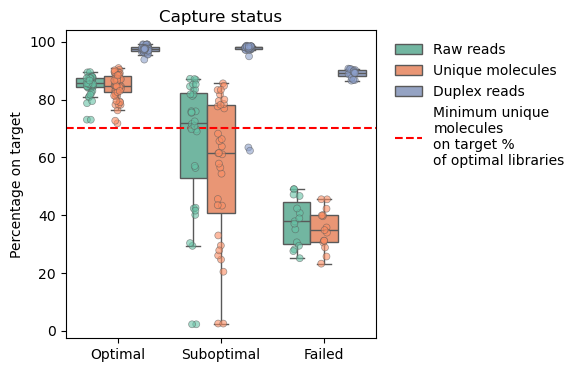

In [ ]:
# your variables of interest
to_plot = [
    'BamQC>>raw.percentage_aligned_on_target',
    'BamQC>>am.percentage_aligned_on_target',
    'BamQC>>duplex.percentage_aligned_on_target',
    # 'FamMetrics>>on_target'
]

# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
                             'IDT016', 'IDT017', 'IDT018','IDT020',
                             'IDT015','IDT021', 'IDT022',
                             'IDT023', 'IDT019',
                             'IDT026',
                             'IDT027',
                             ])].copy()

mapping_batch_to_quality = {
        "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                    'IDT016', 'IDT017', 'IDT018','IDT020',
                    'IDT026','IDT027',
                    ],
        "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
        "Failed": [ 'IDT023', 'IDT019']
    }

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})

df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name="Percentage_on_target"
)

# rename Metric column for nicer display
long_df["Metric"] = long_df["Metric"].str.replace("BamQC>>", "").str.replace(".percentage_aligned_on_target", "")
long_df["Metric"] = long_df["Metric"].map({
    'raw': 'Raw reads',
    'am': 'Unique molecules',
    'duplex': 'Duplex reads',})
# set up plot
plt.figure(figsize=(4, 4))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    palette="Set2",
    order = ["Optimal", "Suboptimal", "Failed"],
    showfliers=False
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y="Percentage_on_target",
    hue="Metric",
    dodge=True,
    alpha=0.6,
    order = ["Optimal", "Suboptimal", "Failed"],
    palette="Set2",
    linewidth=0.5,
    edgecolor="gray",
    legend=False
)
plt.axhline(y=70, color='red', linestyle='--', label='Minimum unique\nmolecules\non target %\nof optimal libraries')
# tidy up
plt.title("Capture status", fontsize=12)
plt.xlabel("")
plt.xticks(range(len(df["CaptureStatus"].unique())), ["Optimal", "Suboptimal", "Failed"])
plt.ylabel("Percentage on target")
# plt.xticks(range(len(df["PROJECT"].unique())), [f"Exp_{i}" for i in range(len(df["PROJECT"].unique()))])
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc='upper left', frameon =False)
# plt.tight_layout()
plt.savefig("plots/capture_status_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()


In [8]:
# # subset data
# df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
# df = df[df["PROJECT"].isin([
#     'IDT007', 'IDT012', 'IDT013', 'IDT014',
#                              'IDT016', 'IDT017', 'IDT018','IDT020',
#                              'IDT015','IDT021', 'IDT022',
#                              'IDT023', 'IDT019',
#                              'IDT026',
#                              'IDT027',
#                              ])].copy()

# mapping_batch_to_quality = {
#         "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
#                     'IDT016', 'IDT017', 'IDT018','IDT020',
#                     'IDT026','IDT027',
#                     ],
#         "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
#         "Failed": [ 'IDT023', 'IDT019']
#     }

# df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})

# df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)



# # your variables of interest
# to_plot = [
#     # 'Combined>>recovery.input_ng2duplex_depth',
#     'DryLab>>on_target.duplex.efficiency',
# ]

# # reshape from wide to long format
# long_df = df.melt(
#     id_vars="CaptureStatus",
#     value_vars=to_plot,
#     var_name="Metric",
#     value_name="Percentage_on_target"
# )

# # rename Metric column for nicer display
# long_df["Metric"] = long_df["Metric"].str.replace("BamQC>>", "").str.replace(".percentage_aligned_on_target", "").str.replace("am", "unique molecules")

# # set up plot
# plt.figure(figsize=(6, 4))
# sns.boxplot(
#     data=long_df,
#     x="CaptureStatus",
#     y="Percentage_on_target",
#     hue="Metric",
#     palette="Set2",
#     order = ["Optimal", "Suboptimal", "Failed"],
#     showfliers=False
# )
# sns.stripplot(
#     data=long_df,
#     x="CaptureStatus",
#     y="Percentage_on_target",
#     hue="Metric",
#     dodge=True,
#     alpha=0.6,
#     order = ["Optimal", "Suboptimal", "Failed"],
#     palette="Set2",
#     linewidth=0.5,
#     edgecolor="gray",
#     legend=False
# )
# # plt.axhline(y=70, color='red', linestyle='--', label='Mean on-target %\nof libraries\nwith successful\ncapture')  # vertical line to separate batches
# # tidy up
# plt.title("Capture status per experiment batch", fontsize=12)
# plt.xlabel("")
# plt.ylabel("Percentage Aligned on Target (%)")
# # plt.xticks(range(len(df["PROJECT"].unique())), [f"Exp_{i}" for i in range(len(df["PROJECT"].unique()))])
# plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc='upper left')
# plt.tight_layout()
# plt.savefig("capture_status_plot.png", dpi=300, bbox_inches='tight')
# plt.show()


In [9]:
# # subset data
# df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
# df = df[df["PROJECT"].isin([
#     'IDT007', 'IDT012', 'IDT013', 'IDT014',
#     'IDT016', 'IDT017', 'IDT018','IDT020',
#     'IDT015','IDT021', 'IDT022',
#     'IDT023', 'IDT019',
#     'IDT026',
#     'IDT027',
# ])].copy()

# mapping_batch_to_quality = {
#     "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
#                 'IDT016', 'IDT017', 'IDT018','IDT020',
#                 'IDT026','IDT027',
#                 ],
#     "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
#     "Failed": [ 'IDT023', 'IDT019']
# }

# df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
# df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# # your variables of interest
# to_plot = [
#     'Combined>>recovery.input_ng2duplex_depth',
# #     'DryLab>>on_target.duplex.efficiency',
# ]
# value = "Recovery"

# # reshape from wide to long format
# long_df = df.melt(
#     id_vars="CaptureStatus",
#     value_vars=to_plot,
#     var_name="Metric",
#     value_name=value
# )


# # set up plot (swapping x and y for horizontal orientation)
# plt.figure(figsize=(4, 3))
# sns.boxplot(
#     data=long_df,
#     y="CaptureStatus",
#     x=value,
#     color = "salmon",
#     order = ["Optimal", "Suboptimal", "Failed"],
#     showfliers=False,
#     orient='h'
# )
# sns.stripplot(
#     data=long_df,
#     y="CaptureStatus",
#     x=value,
#     dodge=True,
#     alpha=0.6,
#     order = ["Optimal", "Suboptimal", "Failed"],
#     color = "salmon",
#     linewidth=0.5,
#     edgecolor="gray",
#     legend=False,
#     orient='h'
# )

# # tidy up
# plt.title("Recovery per capture status", fontsize=12)
# plt.ylabel("Capture Status")
# plt.xlabel("Recovery (input ng / duplex depth)")
# plt.legend().remove()
# plt.savefig("recovery_per_capture_status_plot_horizontal.png", dpi=300, bbox_inches='tight')
# plt.show()

/tmp/ipykernel_2826088/745922792.py:50: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_2826088/745922792.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


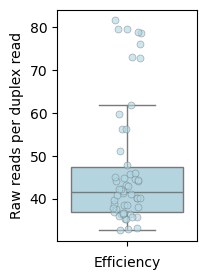

In [ ]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    "OptimalReadXDuplexRead"
    # 'DryLab>>on_target.duplex.efficiency',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "lightblue",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "lightblue",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# tidy up
plt.title("", fontsize=12)
plt.ylabel("Raw reads per duplex read")
plt.xlabel("Efficiency")
plt.xticks([0],[])
plt.legend().remove()
# plt.tight_layout()
plt.savefig("plots/sequencing_efficiency_per_capture_status_plot_horizontal.pdf", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2826088/3835257997.py:49: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(
/tmp/ipykernel_2826088/3835257997.py:68: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


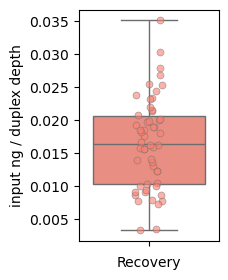

In [ ]:
# subset data
df = subset_data[subset_data["PROJECT"].str.startswith("IDT")].copy()
df = df[df["PROJECT"].isin([
    'IDT007', 'IDT012', 'IDT013', 'IDT014',
    'IDT016', 'IDT017', 'IDT018','IDT020',
    'IDT015','IDT021', 'IDT022',
    'IDT023', 'IDT019',
    'IDT026',
    'IDT027',
])].copy()

mapping_batch_to_quality = {
    "Optimal": ['IDT007', 'IDT012', 'IDT013', 'IDT014',
                'IDT016', 'IDT017', 'IDT018','IDT020',
                'IDT026','IDT027',
                ],
    "Suboptimal" : ['IDT015','IDT021', 'IDT022',],
    "Failed": [ 'IDT023', 'IDT019']
}

df["CaptureStatus"] = df["PROJECT"].map({proj: status for status, projs in mapping_batch_to_quality.items() for proj in projs})
df = df.sort_values(by = "CaptureStatus").reset_index(drop=True)

# your variables of interest
to_plot = [
    'Combined>>recovery.input_ng2duplex_depth',
]
value = "Recovery"

# reshape from wide to long format
long_df = df.melt(
    id_vars="CaptureStatus",
    value_vars=to_plot,
    var_name="Metric",
    value_name=value
)


# set up plot (swapping x and y for horizontal orientation)
plt.figure(figsize=(1.8, 3))
sns.boxplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    color = "salmon",
    order = ["Optimal"],
    showfliers=False,
)
sns.stripplot(
    data=long_df,
    x="CaptureStatus",
    y=value,
    dodge=True,
    alpha=0.6,
    order = ["Optimal"],
    color = "salmon",
    linewidth=0.5,
    edgecolor="gray",
    legend=False,

)

# # tidy up
plt.title("", fontsize=12)
plt.ylabel("input ng / duplex depth")
plt.xlabel("Recovery")
plt.xticks([0],[])
plt.legend().remove()
plt.savefig("plots/recovery_per_capture_status_plot.pdf", dpi=300, bbox_inches='tight')
plt.show()